# Count the number of colocalization points in the Mediterranean sea

- Should be under SWOT swath during the fast sampling period

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from medlib.cstes import swot_dir, drifters_dir
from medlib.swot import browse_swot#, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from rasterio.transform import Affine

import pynsitu as pyn

/Users/mdemol/code/pynsitu/pynsitu/__init__.py:45: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  hour = Timedelta("1H")


/Users/mdemol/opt/anaconda3/envs/mdenv/lib/python3.9/site-packages/pyTMD/tools.py:55: UserWarning: ipyleaflet not available
  warnings.warn("ipyleaflet not available")
/Users/mdemol/opt/anaconda3/envs/mdenv/lib/python3.9/site-packages/pyTMD/tools.py:56: UserWarning: Some functions will throw an exception if called
  warnings.warn("Some functions will throw an exception if called")


_______
# SWOT

In [2]:
dfs = browse_swot().reset_index()
dfs

,day,pass_number,cycle_number,file,time
0,2023-04-01,3,478,/Users/mdemol/DATA_KARIN/3_478.zarr,2023-04-01 23:42:32.696536000
1,2023-04-02,3,479,/Users/mdemol/DATA_KARIN/3_479.zarr,2023-04-02 23:33:10.425673088
2,2023-04-03,3,480,/Users/mdemol/DATA_KARIN/3_480.zarr,2023-04-03 23:23:48.189185728
3,2023-04-04,3,481,/Users/mdemol/DATA_KARIN/3_481.zarr,2023-04-04 23:14:25.904031360
4,2023-04-05,3,482,/Users/mdemol/DATA_KARIN/3_482.zarr,2023-04-05 23:05:03.656492928
...,...,...,...,...,...
182,2023-07-05,16,573,/Users/mdemol/DATA_KARIN/16_573.zarr,2023-07-05 19:33:50.331633280
183,2023-07-06,16,574,/Users/mdemol/DATA_KARIN/16_574.zarr,2023-07-06 19:24:28.273369600
184,2023-07-07,16,575,/Users/mdemol/DATA_KARIN/16_575.zarr,2023-07-07 19:15:06.145279168
185,2023-07-08,16,576,/Users/mdemol/DATA_KARIN/16_576.zarr,2023-07-08 19:05:44.003893184


In [46]:
import geopandas as gpd
import shapely as shp
from shapely.geometry import Polygon

def build_swath_polygon(da, x="x", y="y", dix = 50, diy = 50, side=None):
    """ build a shapely polygon of swot swath

    Parameters
    ----------
    da: xr.Dataset, xr.DataArray
        Input dataset where coordinates x/y are found
    x, y: str, optional
        Coordinates to use to define bounds
    dix, diy: int, optional
        Subsampling steps in num_pixels and num_lines directions
    side: str, optional
        take either the polygon for the full swath, or the right/left ones
    """

    # right swath
    if side=="left":
        da = da.isel(num_pixels=slice(0, 237))
    elif side=="right":
        da = da.isel(num_pixels=slice(282, -1))
            
    nx = da.num_pixels.size
    ny = da.num_lines.size
        
    rg = lambda size, di: list(range(0, size, di))+[size-1]
    
    X, Y = [], []
    
    e = da.isel(num_lines=0, num_pixels=rg(nx, dix))
    X += list(e[x].data)
    Y += list(e[y].data)
    
    e = da.isel(num_lines=-1, num_pixels=rg(nx, dix))
    X += list(e[x].data)
    Y += list(e[y].data)
    
    e = da.isel(num_lines=rg(ny,diy), num_pixels=0)
    X += list(e[x].data)
    Y += list(e[y].data)
    
    e = da.isel(num_lines=rg(ny,diy), num_pixels=-1)
    X += list(e[x].data)
    Y += list(e[y].data)
    
    mpt = shp.MultiPoint([[x, y] for x, y in zip(X, Y)])
    poly = mpt.convex_hull

    return poly, X, Y

def add_mask_inside_swot(ds_swot, ds_drifters, dix = 50, diy = 50):
    # build swath polygons
    #both = build_swath_polygon(swot, x="longitude", y="latitude", dix = 50, diy = 50, side=None)
    left = build_swath_polygon(ds_swot, x="longitude", y="latitude", dix=dix, diy=diy, side="left")[0]
    right = build_swath_polygon(ds_swot, x="longitude", y="latitude", dix=dix, diy=diy, side="right")[0]
    Xl, Yl = build_swath_polygon(ds_swot, x="longitude", y="latitude", dix=dix, diy=diy, side="left")[1:]
    Xr, Yr = build_swath_polygon(ds_swot, x="longitude", y="latitude", dix=dix, diy=diy, side="right")[1:]
    
    # stack dimensions
    drs = ds_drifters.stack(points=("datetime", "drifter_id"))
    lon, lat = drs.longitude.fillna(0.).values, drs.latitude.fillna(0.).values
    # test if points inside right swath
    drs["inside_right"] = (
        "points", 
        np.array([right.contains(shp.Point(_lon, _lat)) for _lon, _lat in zip(lon, lat)]),
    )
    # test if points inside left swath
    drs["inside_left"] = (
        "points", 
        np.array([left.contains(shp.Point(_lon, _lat)) for _lon, _lat in zip(lon, lat)]),
    )
    # put mask inside original dataset
    ds_drifters["inside_left"] = drs["inside_left"].unstack()
    ds_drifters["inside_right"] = drs["inside_right"].unstack()
    return ds_drifters, Xl, Yl, Xr, Yr

In [50]:
def select_data(cycle, swath, dfs):
    # SWOT
    df = dfs.where(dfs.pass_number==int(swath)).dropna()
    dss = xr.open_dataset(df.set_index('cycle_number').loc[cycle].file)
    dss['num_lines']=np.arange(len(dss.num_lines))
    dss['num_pixels']=np.arange(len(dss.num_pixels))
    
    dss['eta'] = dss.cvl_mean_dynamic_topography_cnes_cls_22 + dss.cvl_ocean_tide_fes_2022 + dss.duacs_ssha_karin_2_filtered
    dss.eta.attrs={'long_name':'ADT+ocean tide correction', 'unit':'m'}

    # DRIFTERS
    time = pd.to_datetime(dss.time.mean().values).round('min')
    #dt = pd.Timedelta('12h')#drifters points for whose the SWOT images is the nearest one (less precise)
    dt = df.time.diff().median() #drifters points for whose the SWOT images is the nearest one (more precise)
    dr = xr.open_dataset(os.path.join(drifters_dir, 'all_med_variational_1h_v0.nc'))
    dr_key = dr[['cruise_id', 'drifter_type']]
    dr = dr.where(dr.gap_mask==1)
    # Time selection
    dr_=dr
    #dr_ = dr.sel(datetime = slice(time-dt, time+dt))
    # Under inside SWOT 
    dr_, Xl, Yl, Xr, Yr = add_mask_inside_swot(dss, dr_)
    dr__ = dr_.where(dr_["inside_left"]+dr_["inside_right"])
    
    return dss, dr__, dr_key, Xl, Yl, Xr, Yr

Text(0.5, 1.0, 'Swath n°3, Cycle n°479\n04-02-2023 23:34')

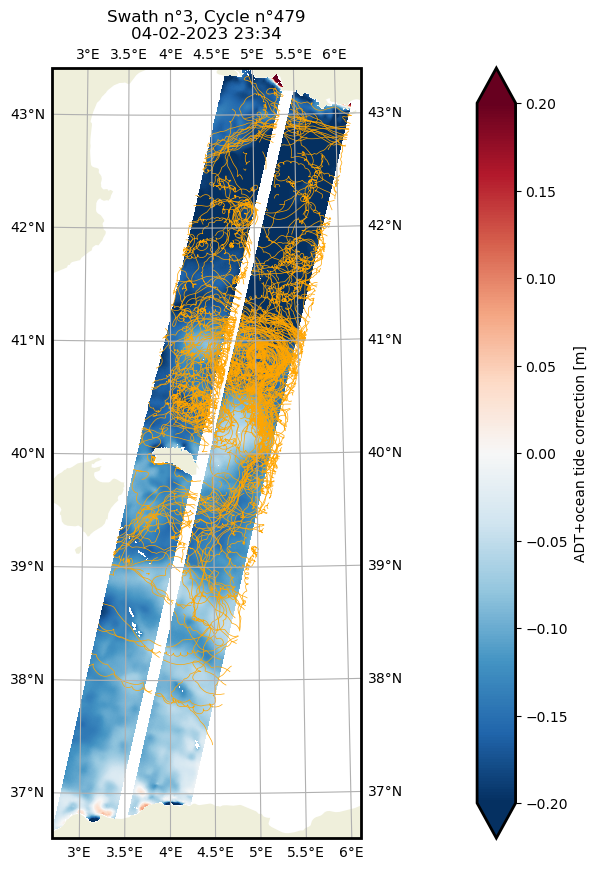

In [55]:
lon=4
lat=39.3

cycle=479#520
swath=3
dss, dr, dr_key, Xl, Yl, Xr, Yr= select_data(cycle, swath, dfs)

if swath == 3 : 
    bbox = [2.7, 6.1, 36.6, 43.4]
    #bbox = [3.5, 6.1, 40, 43.4]
    vmax=0.2
    vmin=-0.2

if swath == 16 : 
    #bbox = [0.9, 3.7, 36.5, 41.5]
    bbox = [0.9, 3.7, 38, 41.5]
    vmax=0.2
    vmin=-0.2

fig = plt.figure(figsize=(10,10))
fig.patch.set_facecolor('white')#no transparancy in png
ax = fig.add_subplot(111, projection=ccrs.Orthographic(lon, lat))

dss.eta.plot(x='longitude', y='latitude', transform=crs, ax=ax, 
             vmin=vmin, 
             vmax=vmax,
             cmap='RdBu_r',
             cbar_kwargs={"pad": 0.15}
            )

for id in dr.drifter_id : 
    dr_ = dr.sel(drifter_id=id)
    key = str(dr_key.sel(drifter_id=id)['cruise_id'].values)+': '+str(dr_key.sel(drifter_id=id)['drifter_type'].values)
    if dr_.longitude.dropna('datetime').size==0:
        continue
    else :
        ax.plot(dr_.longitude, dr_.latitude, transform=crs, c='orange', lw=0.5)
        #ax.plot(dr_.longitude.dropna('datetime')[-1], dr_.latitude.dropna('datetime')[-1], marker='x', markersize=3, transform=crs, c='orange', lw=0.5)
        #ax.plot(dr_.longitude, dr_.latitude, transform=crs, c=color[key], label=key, lw=0.5)

ax.add_feature(cfeature.LAND,)
ax.set_extent(bbox)

gl = ax.gridlines(draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_right = False

time = pd.to_datetime(dss.time.mean().values).round('min')
ax.set_title(f'Swath n°{swath}, Cycle n°{cycle}'+'\n'+f'{time.strftime("%m-%d-%Y %H:%M")}')
#hand, lab = set_legend(handles, labels)
#ax.legend(hand, lab)
#fig.tight_layout()


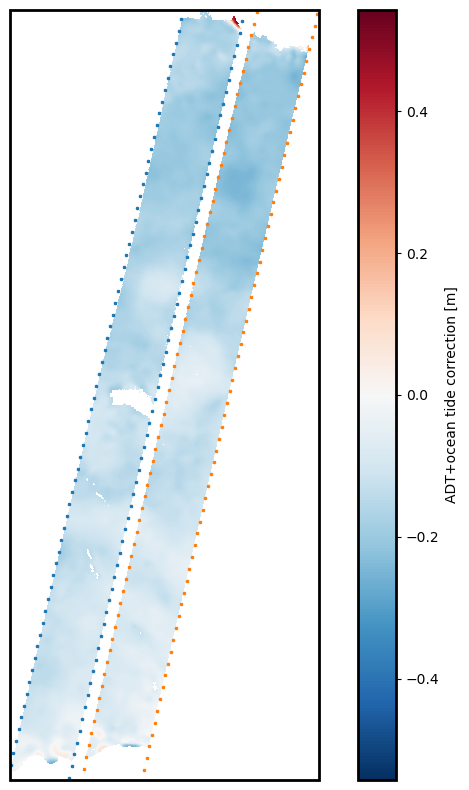

In [59]:
fig = plt.figure(figsize=(10,10))
fig.patch.set_facecolor('white')#no transparancy in png
ax = fig.add_subplot(111, projection=ccrs.Orthographic(lon, lat))

dss.eta.plot(x='longitude', y='latitude',ax=ax, transform=crs,)
ax.scatter(Xl, Yl, marker='x', s=3, transform=crs,)
ax.scatter(Xr, Yr, marker='x', s=3, transform=crs,)
ax.set_extent(bbox)